# Лабораторная 4
###### После перезапуска ядра сломался вывод tqdm (перестал удалять пройденные эпохи), это баг буферизации pycharm, который решить не удалось

## Задача классификации цветов автомобилей

### Дообучить два классификатора цветов машин на наборе данных DVM, взяв модели, предобученные на ImageNet и на чем-то другом.

#### 1. Подготовка данных

In [1]:
import os
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from torchvision import models
import copy
from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm
from collections import defaultdict
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"{device}")

cuda


##### Убрал классы многоцветных машин и не размеченных машин так как по сути они являются шумом и не содержат повторяющихся признаков внутри класса (кроме того что это машина)

In [2]:
blacklist = ['multicolour', 'unlisted']

##### Также объединил цвета и их оттенки (например Navy это темно-синий, соответственно оттенок синего)
###### Без этого метрика f1 в среднем меньше на 0,2 для всех моделей

In [3]:
color_mapping_dict = {
        'silver': 'grey',
        'navy': 'blue',
        'indigo': 'blue',
        'burgundy': 'red',
        'maroon': 'red',
        'bronze': 'brown',
        'magenta': 'purple',
        'gold': 'yellow'
    }

In [4]:
def parse_dir(root_dir):
    image_paths = []
    labels = []
    color_to_idx = {}

    for brand in os.listdir(root_dir):
        brand_path = os.path.join(root_dir, brand)
        if not os.path.isdir(brand_path):
            continue
        for model in os.listdir(brand_path):
            model_path = os.path.join(brand_path, model)
            if not os.path.isdir(model_path):
                continue
            for year in os.listdir(model_path):
                year_path = os.path.join(model_path, year)
                if not os.path.isdir(year_path):
                    continue
                for color in os.listdir(year_path):
                    if color.lower() in blacklist:
                        continue

                    final_color = color_mapping_dict.get(color.lower(), color.lower())
                    color_path = os.path.join(year_path, color)
                    if not os.path.isdir(color_path):
                        continue

                    if final_color not in color_to_idx:
                        color_to_idx[final_color] = len(color_to_idx)

                    for img_file in os.listdir(color_path):
                        if img_file.lower().endswith('.jpg'):
                            image_paths.append(os.path.join(color_path, img_file))
                            labels.append(color_to_idx[final_color])

    print(f"Картинки {len(image_paths)}, цвета {len(color_to_idx)}")
    for a in color_to_idx:
        print(f"{a}: {color_to_idx[a]}")

    return image_paths, labels, color_to_idx

In [5]:
class MyDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            image = Image.new('RGB', (224, 224), (0, 0, 0))

        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [6]:
data_root = "resized_DVM_v2/resized_DVM"

all_paths, all_labels, color_mapping = parse_dir(data_root)
idx_to_color = {v: k for k, v in color_mapping.items()}

max_images_per_class = 3000
class_dict = defaultdict(list)

for p, l in zip(all_paths, all_labels):
    class_dict[l].append(p)

strat_paths = []
strat_labels = []

for label, paths_list in class_dict.items():
    if len(paths_list) > max_images_per_class:
        np.random.seed(42)
        np.random.shuffle(paths_list)
        paths_list = paths_list[:max_images_per_class]

    strat_paths.extend(paths_list)
    strat_labels.extend([label] * len(paths_list))

train_val_paths,test_paths,train_val_labels,test_labels = train_test_split(
    strat_paths, strat_labels, test_size=0.15, random_state=42, stratify=strat_labels
)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths, train_val_labels, test_size=0.15, random_state=42, stratify=train_val_labels
)

Картинки 1417111, цвета 13
blue: 0
grey: 1
red: 2
white: 3
black: 4
yellow: 5
green: 6
beige: 7
brown: 8
turquoise: 9
orange: 10
purple: 11
pink: 12


In [7]:
epochs= 30
lr= 1e-3
weight_decay= 1e-4
batch_size= 64

In [8]:
train_transform= transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
])

eval_transform= transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset= MyDataset(train_paths, train_labels, transform=train_transform)
val_dataset= MyDataset(val_paths, val_labels, transform=eval_transform)
test_dataset = MyDataset(test_paths, test_labels, transform=eval_transform)

train_loader= DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader= DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Трейн {len(train_dataset)}, валидация {len(val_dataset)}, тест {len(test_dataset)}")

Трейн 25900, валидация 4571, тест 5378


#### 2.1 Реализация с предобученной моделью на ImageNet

In [9]:
class TransferRes(nn.Module):
    def __init__(self, num_classes):
        super(TransferRes, self).__init__()

        self.backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

        for param in self.backbone.parameters():
            param.requires_grad = False

        num_features = self.backbone.fc.in_features

        self.backbone.fc = nn.Sequential(
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(0.5)
        )

        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        embeddings = self.backbone(x)
        out = self.classifier(embeddings)
        return out

In [10]:
num_classes=len(color_mapping)

model_transfer = TransferRes(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model_transfer.parameters()),lr=lr, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print(f"{sum(p.numel() for p in model_transfer.parameters() if p.requires_grad):,}")

527,885


In [11]:
model = model_transfer

history_1 = {'train_loss': [], 'train_acc': [], 'train_f1': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_val_f1 = 0.0
weights = copy.deepcopy(model.state_dict())
best_loss = 1000.0
cnt = 0
cnt2 = 0

for epoch in range(epochs):
    model.train()
    train_loss = 0
    all_train_preds, all_train_labels = [], []

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)

    for images, labels in train_bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        all_train_preds.extend(predicted.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())

        train_bar.set_postfix(loss=loss.item())
    train_bar.close()
    train_bar.display(close=True)

    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = accuracy_score(all_train_labels, all_train_preds)
    epoch_train_f1 = f1_score(all_train_labels, all_train_preds, average='macro', zero_division=0)

    model.eval()
    val_loss = 0
    all_val_preds, all_val_labels = [], []

    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False)

    with torch.no_grad():
        for images, labels in val_bar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)

            all_val_preds.extend(predicted.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())
        val_bar.close()
        val_bar.display(close=True)
    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = accuracy_score(all_val_labels, all_val_preds)
    epoch_val_f1 = f1_score(all_val_labels, all_val_preds, average='macro', zero_division=0)

    scheduler.step(avg_val_loss)

    history_1['train_loss'].append(avg_train_loss)
    history_1['val_loss'].append(avg_val_loss)
    history_1['train_acc'].append(avg_train_acc)
    history_1['val_acc'].append(avg_val_acc)
    history_1['train_f1'].append(epoch_train_f1)
    history_1['val_f1'].append(epoch_val_f1)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.3f} F1: {epoch_train_f1:.3f} | Val Loss: {avg_val_loss:.3f} F1: {epoch_val_f1:.3f}")

    if epoch_val_f1 > best_val_f1 and (avg_val_loss < best_loss or avg_val_loss - best_loss < 0.01):
        best_val_f1 = epoch_val_f1
        best_loss = avg_val_loss
        weights = copy.deepcopy(model.state_dict())
        cnt2 = 0
        print("сохранено")

    if best_val_f1 - epoch_val_f1 < 0.05:
        cnt2 += 1
    if cnt2 == 5:
        print(f"F1 на валидации не улучшается {cnt} эпох")
        break

    if epoch_train_f1 - epoch_val_f1 > 0.15:
        cnt += 1
    else:
        cnt = 0
    if cnt == 5:
        print(f"Переобучение разрыв F1: {(epoch_train_f1 - epoch_val_f1)*100:.2f}%")
        break

model.load_state_dict(weights)
model.eval()
all_test_preds, all_test_labels = [], []

test_bar = tqdm(test_loader, desc="Testing")
with torch.no_grad():
    for images, labels in test_bar:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_test_preds.extend(predicted.cpu().numpy())
        all_test_labels.extend(labels.cpu().numpy())

final_test_acc = accuracy_score(all_test_labels, all_test_preds)
final_test_f1 = f1_score(all_test_labels, all_test_preds, average='macro', zero_division=0)

print(f"Лучшая F1 на валидации: {best_val_f1:.3f}")
print(f"Итоговые оценки Acc: {final_test_acc:.3f} | F1: {final_test_f1:.3f}")

Epoch 1/30 [Train]:   0%|          | 0/405 [00:00<?, ?it/s]

Epoch 1/30 [Val]:   0%|          | 0/72 [00:00<?, ?it/s]

Epoch 1/30 | Train Loss: 1.772 F1: 0.477 | Val Loss: 1.561 F1: 0.549
сохранено


Epoch 2/30 [Train]:   0%|          | 0/405 [00:00<?, ?it/s]

Epoch 2/30 [Val]:   0%|          | 0/72 [00:00<?, ?it/s]

...

Epoch 13/30 [Train]:   0%|          | 0/405 [00:00<?, ?it/s]

Epoch 13/30 [Val]:   0%|          | 0/72 [00:00<?, ?it/s]

Epoch 13/30 | Train Loss: 1.402 F1: 0.652 | Val Loss: 1.413 F1: 0.648
F1 на валидации не улучшается 0 эпох


Testing:   0%|          | 0/85 [00:00<?, ?it/s]

Лучшая F1 на валидации: 0.654
Итоговые оценки Acc: 0.636 | F1: 0.642


##### Вариант с обучением внутренних слоев предобученной модели для сравнения

In [12]:
class DeepRes(nn.Module):
    def __init__(self, num_classes):
        super(DeepRes, self).__init__()
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

model_res2 = DeepRes(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW([
    {'params': model_res2.backbone.conv1.parameters(), 'lr': lr* 0.01},
    {'params': model_res2.backbone.bn1.parameters(), 'lr': lr* 0.01},
    {'params': model_res2.backbone.layer1.parameters(), 'lr': lr* 0.01},
    {'params': model_res2.backbone.layer2.parameters(), 'lr': lr* 0.1},
    {'params': model_res2.backbone.layer3.parameters(), 'lr': lr* 0.1},
    {'params': model_res2.backbone.layer4.parameters(), 'lr': lr* 0.5},
    {'params': model_res2.backbone.fc.parameters(),    'lr': lr}
], weight_decay=weight_decay)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
print(f"{sum(p.numel() for p in model_res2.parameters() if p.requires_grad):,}")

23,534,669


In [13]:
model = model_res2

history_2 = {'train_loss': [], 'train_acc': [], 'train_f1': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_val_f1 = 0.0
weights = copy.deepcopy(model.state_dict())
best_loss = 1000.0
cnt = 0
cnt2 = 0

for epoch in range(epochs):
    model.train()
    train_loss = 0
    all_train_preds, all_train_labels = [], []

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)

    for images, labels in train_bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        all_train_preds.extend(predicted.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())

        train_bar.set_postfix(loss=loss.item())
    train_bar.close()
    train_bar.display(close=True)

    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = accuracy_score(all_train_labels, all_train_preds)
    epoch_train_f1 = f1_score(all_train_labels, all_train_preds, average='macro', zero_division=0)

    model.eval()
    val_loss = 0
    all_val_preds, all_val_labels = [], []

    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False)

    with torch.no_grad():
        for images, labels in val_bar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)

            all_val_preds.extend(predicted.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())
        val_bar.close()
        val_bar.display(close=True)

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = accuracy_score(all_val_labels, all_val_preds)
    epoch_val_f1 = f1_score(all_val_labels, all_val_preds, average='macro', zero_division=0)

    scheduler.step(avg_val_loss)

    history_2['train_loss'].append(avg_train_loss)
    history_2['val_loss'].append(avg_val_loss)
    history_2['train_acc'].append(avg_train_acc)
    history_2['val_acc'].append(avg_val_acc)
    history_2['train_f1'].append(epoch_train_f1)
    history_2['val_f1'].append(epoch_val_f1)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.3f} F1: {epoch_train_f1:.3f} | Val Loss: {avg_val_loss:.3f} F1: {epoch_val_f1:.3f}")

    if epoch_val_f1 > best_val_f1 and (avg_val_loss < best_loss or avg_val_loss - best_loss < 0.01):
        best_val_f1 = epoch_val_f1
        best_loss = avg_val_loss
        weights = copy.deepcopy(model.state_dict())
        cnt2 = 0
        print("сохранено")

    if best_val_f1 - epoch_val_f1 < 0.05:
        cnt2 += 1
    if cnt2 == 5:
        print(f"F1 на валидации не улучшается {cnt} эпох")
        break

    if epoch_train_f1 - epoch_val_f1 > 0.15:
        cnt += 1
    else:
        cnt = 0
    if cnt == 5:
        print(f"Переобучение Разрыв F1: {(epoch_train_f1 - epoch_val_f1)*100:.2f}%")
        break

model.load_state_dict(weights)
model.eval()
all_test_preds, all_test_labels = [], []

test_bar = tqdm(test_loader, desc="Testing")
with torch.no_grad():
    for images, labels in test_bar:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_test_preds.extend(predicted.cpu().numpy())
        all_test_labels.extend(labels.cpu().numpy())

final_test_acc = accuracy_score(all_test_labels, all_test_preds)
final_test_f1 = f1_score(all_test_labels, all_test_preds, average='macro', zero_division=0)

print(f"Лучшая F1 на валидации: {best_val_f1:.3f}")
print(f"Итоговые оценки Acc: {final_test_acc:.3f} | F1: {final_test_f1:.3f}")

Epoch 1/30 [Train]:   0%|          | 0/405 [00:00<?, ?it/s]

Epoch 1/30 [Val]:   0%|          | 0/72 [00:00<?, ?it/s]

Epoch 1/30 | Train Loss: 1.321 F1: 0.683 | Val Loss: 1.103 F1: 0.780
сохранено


Epoch 2/30 [Train]:   0%|          | 0/405 [00:00<?, ?it/s]

Epoch 2/30 [Val]:   0%|          | 0/72 [00:00<?, ?it/s]

...

Epoch 8/30 [Train]:   0%|          | 0/405 [00:00<?, ?it/s]

Epoch 8/30 [Val]:   0%|          | 0/72 [00:00<?, ?it/s]

Epoch 8/30 | Train Loss: 0.754 F1: 0.923 | Val Loss: 1.005 F1: 0.832
F1 на валидации не улучшается 0 эпох


Testing:   0%|          | 0/85 [00:00<?, ?it/s]

Лучшая F1 на валидации: 0.828
Итоговые оценки Acc: 0.821 | F1: 0.827


#### 2.2 Реализация с предобученной моделью на MS COCO

In [14]:
detection_model = models.detection.fasterrcnn_resnet50_fpn(weights=models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT)

class CocoRes(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.backbone = detection_model.backbone.body

        for param in self.backbone.parameters():
            param.requires_grad = False

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        x = features['3']
        x = self.pool(x)
        x = self.classifier(x)
        return x

In [15]:
model_coco= CocoRes(num_classes=num_classes).to(device)
criterion= nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer= optim.AdamW(filter(lambda p: p.requires_grad, model_coco.parameters()),lr=lr, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
print(f"{sum(p.numel() for p in model_coco.parameters() if p.requires_grad):,}")

1,055,757


In [16]:
model = model_coco

history_3 = {'train_loss': [], 'train_acc': [], 'train_f1': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_val_f1 = 0.0
weights = copy.deepcopy(model.state_dict())
best_loss = 1000.0
cnt = 0
cnt2 = 0

for epoch in range(epochs):
    model.train()
    train_loss = 0
    all_train_preds, all_train_labels = [], []

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)

    for images, labels in train_bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        all_train_preds.extend(predicted.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())

        train_bar.set_postfix(loss=loss.item())
    train_bar.close()
    train_bar.display(close=True)

    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = accuracy_score(all_train_labels, all_train_preds)
    epoch_train_f1 = f1_score(all_train_labels, all_train_preds, average='macro', zero_division=0)

    model.eval()
    val_loss = 0
    all_val_preds, all_val_labels = [], []

    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False)

    with torch.no_grad():
        for images, labels in val_bar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)

            all_val_preds.extend(predicted.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())
        val_bar.close()
        val_bar.display(close=True)

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = accuracy_score(all_val_labels, all_val_preds)
    epoch_val_f1 = f1_score(all_val_labels, all_val_preds, average='macro', zero_division=0)

    scheduler.step(avg_val_loss)

    history_3['train_loss'].append(avg_train_loss)
    history_3['val_loss'].append(avg_val_loss)
    history_3['train_acc'].append(avg_train_acc)
    history_3['val_acc'].append(avg_val_acc)
    history_3['train_f1'].append(epoch_train_f1)
    history_3['val_f1'].append(epoch_val_f1)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.3f} F1: {epoch_train_f1:.3f} | Val Loss: {avg_val_loss:.3f} F1: {epoch_val_f1:.3f}")

    if epoch_val_f1 > best_val_f1 and (avg_val_loss < best_loss or avg_val_loss - best_loss < 0.01):
        best_val_f1 = epoch_val_f1
        best_loss = avg_val_loss
        weights = copy.deepcopy(model.state_dict())
        cnt2 = 0
        print("сохранено")

    if best_val_f1 - epoch_val_f1 < 0.05:
        cnt2 += 1
    if cnt2 == 5:
        print(f"F1 на валидации не улучшается {cnt} эпох")
        break

    if epoch_train_f1 - epoch_val_f1 > 0.15:
        cnt += 1
    else:
        cnt = 0
    if cnt == 5:
        print(f"Переобучение разрыв F1: {(epoch_train_f1 - epoch_val_f1)*100:.2f}%")
        break

model.load_state_dict(weights)
model.eval()
all_test_preds, all_test_labels = [], []

test_bar = tqdm(test_loader, desc="Testing")
with torch.no_grad():
    for images, labels in test_bar:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_test_preds.extend(predicted.cpu().numpy())
        all_test_labels.extend(labels.cpu().numpy())

final_test_acc = accuracy_score(all_test_labels, all_test_preds)
final_test_f1 = f1_score(all_test_labels, all_test_preds, average='macro', zero_division=0)

print(f"Лучшая F1 на валидации: {best_val_f1:.3f}")
print(f"Итоговые оценки Acc: {final_test_acc:.3f} | F1: {final_test_f1:.3f}")

Epoch 1/30 [Train]:   0%|          | 0/405 [00:00<?, ?it/s]

Epoch 1/30 [Val]:   0%|          | 0/72 [00:00<?, ?it/s]

Epoch 1/30 | Train Loss: 2.233 F1: 0.226 | Val Loss: 1.975 F1: 0.338
сохранено


Epoch 2/30 [Train]:   0%|          | 0/405 [00:00<?, ?it/s]

Epoch 2/30 [Val]:   0%|          | 0/72 [00:00<?, ?it/s]

...

Epoch 29/30 [Train]:   0%|          | 0/405 [00:00<?, ?it/s]

Epoch 29/30 [Val]:   0%|          | 0/72 [00:00<?, ?it/s]

Epoch 29/30 | Train Loss: 1.553 F1: 0.580 | Val Loss: 1.508 F1: 0.619
F1 на валидации не улучшается 0 эпох


Testing:   0%|          | 0/85 [00:00<?, ?it/s]

Лучшая F1 на валидации: 0.616
Итоговые оценки Acc: 0.606 | F1: 0.611


### Обучить с нуля собственный классификатор (и обосновать выбор архитектуры)

#### Обоснование: основой выбраны residual блоки, т.к. ообычные последовательности быстро упираются в предел точности, а при наращивании слоев деградируют из-за проблемы затухания градиентов. На входе реализован блок (свертка 7x7 и MaxPool), который сходу режет размерность тензора и расширяет поле фильтра для экономии ресурсов. Использование GAP перед классификатором обусловлено тем, что эта операция схлопывает карты признаков до 1х1, что во-первых сильно снижает количество параметров и делает модель более легковесной, а во-вторых блокирует возможность зазубривания датасета

In [17]:
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResBlock, self).__init__()
        self.conv1= nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 =nn.BatchNorm2d(out_channels)
        self.relu=nn.ReLU(inplace=True)
        self.conv2 =nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2= nn.BatchNorm2d(out_channels)

        self.shortcut= nn.Sequential()
        if stride !=1 or in_channels!= out_channels:
            self.shortcut= nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = self.relu(out)
        return out

In [18]:
class MyModel(nn.Module):
    def __init__(self, num_classes):
        super(MyModel, self).__init__()

        self.block = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.layer1 = ResBlock(64, 64, stride=1)
        self.layer2 = ResBlock(64, 128, stride=2)
        self.layer3 = ResBlock(128, 256, stride=2)

        self.avg_pool= nn.AdaptiveAvgPool2d((1, 1))

        self.classifier =nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256,num_classes)
        )

    def forward(self, x):
        x= self.block(x)
        x= self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avg_pool(x)
        x= torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [19]:
mymodel= MyModel(num_classes=num_classes).to(device)
criterion =nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer= optim.AdamW(filter(lambda p: p.requires_grad, mymodel.parameters()),lr=lr, weight_decay=weight_decay)
scheduler=optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print(f"{sum(p.numel() for p in mymodel.parameters() if p.requires_grad):,}")

1,236,045


In [20]:
model = mymodel

history_4 = {'train_loss': [], 'train_acc': [], 'train_f1': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_val_f1 = 0.0
weights = copy.deepcopy(model.state_dict())
best_loss = 1000.0
cnt = 0
cnt2 = 0

for epoch in range(epochs):
    model.train()
    train_loss = 0
    all_train_preds, all_train_labels = [], []

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)

    for images, labels in train_bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        all_train_preds.extend(predicted.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())

        train_bar.set_postfix(loss=loss.item())
    train_bar.close()
    train_bar.display(close=True)

    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = accuracy_score(all_train_labels, all_train_preds)
    epoch_train_f1 = f1_score(all_train_labels, all_train_preds, average='macro', zero_division=0)

    model.eval()
    val_loss = 0
    all_val_preds, all_val_labels = [], []

    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False)

    with torch.no_grad():
        for images, labels in val_bar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)

            all_val_preds.extend(predicted.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())
        val_bar.close()
        val_bar.display(close=True)

    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = accuracy_score(all_val_labels, all_val_preds)
    epoch_val_f1 = f1_score(all_val_labels, all_val_preds, average='macro', zero_division=0)

    scheduler.step(avg_val_loss)

    history_4['train_loss'].append(avg_train_loss)
    history_4['val_loss'].append(avg_val_loss)
    history_4['train_acc'].append(avg_train_acc)
    history_4['val_acc'].append(avg_val_acc)
    history_4['train_f1'].append(epoch_train_f1)
    history_4['val_f1'].append(epoch_val_f1)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.3f} F1: {epoch_train_f1:.3f} | Val Loss: {avg_val_loss:.3f} F1: {epoch_val_f1:.3f}")

    if epoch_val_f1 > best_val_f1 and (avg_val_loss < best_loss or avg_val_loss - best_loss < 0.01):
        best_val_f1 = epoch_val_f1
        best_loss = avg_val_loss
        weights = copy.deepcopy(model.state_dict())
        cnt2 = 0
        print("сохранено")

    if best_val_f1 - epoch_val_f1 < 0.05:
        cnt2 += 1
    if cnt2 == 5:
        print(f"F1 на валидации не улучшается {cnt} эпох")
        break

    if epoch_train_f1 - epoch_val_f1 > 0.15:
        cnt += 1
    else:
        cnt = 0
    if cnt == 5:
        print(f"Переобучение разрыв F1: {(epoch_train_f1 - epoch_val_f1)*100:.2f}%")
        break

model.load_state_dict(weights)
model.eval()
all_test_preds, all_test_labels = [], []

test_bar = tqdm(test_loader, desc="Testing")
with torch.no_grad():
    for images, labels in test_bar:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_test_preds.extend(predicted.cpu().numpy())
        all_test_labels.extend(labels.cpu().numpy())

final_test_acc = accuracy_score(all_test_labels, all_test_preds)
final_test_f1 = f1_score(all_test_labels, all_test_preds, average='macro', zero_division=0)

print(f"Лучшая F1 на валидации: {best_val_f1:.3f}")
print(f"Итоговые оценки Acc: {final_test_acc:.3f} | F1: {final_test_f1:.3f}")

Epoch 1/30 [Train]:   0%|          | 0/405 [00:00<?, ?it/s]

Epoch 1/30 [Val]:   0%|          | 0/72 [00:00<?, ?it/s]

Epoch 1/30 | Train Loss: 1.855 F1: 0.425 | Val Loss: 1.805 F1: 0.435
сохранено


Epoch 2/30 [Train]:   0%|          | 0/405 [00:00<?, ?it/s]

Epoch 2/30 [Val]:   0%|          | 0/72 [00:00<?, ?it/s]

...

Epoch 30/30 [Train]:   0%|          | 0/405 [00:00<?, ?it/s]

Epoch 30/30 [Val]:   0%|          | 0/72 [00:00<?, ?it/s]

Epoch 30/30 | Train Loss: 1.047 F1: 0.810 | Val Loss: 1.127 F1: 0.785


Testing:   0%|          | 0/85 [00:00<?, ?it/s]

Лучшая F1 на валидации: 0.786
Итоговые оценки Acc: 0.775 | F1: 0.782


### Оценить качество при помощи F1_macro. Какой вывод можно сделать из значения метрики?

##### Использование метрики F1 macro вместо Accuracy важно из-за изначального шума и дисбаланса классов в выборке, так как эта оценка физически не позволяет модели накручивать результат исключительно за счет доминирующих цветов, например черного или белого. Ее рост во время обучения показывает, что сверточные фильтры действительно научились извлекать нужные признаки, а не просто выдавать вероятность самого частого класса

### Сравнить полученное качество и сделать вывод

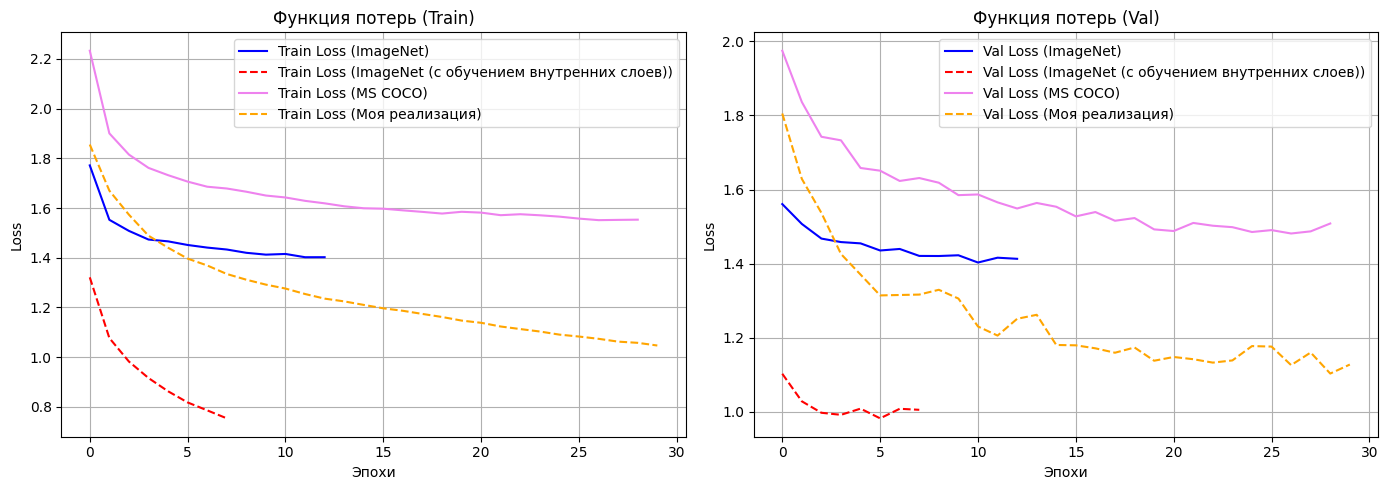

In [21]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_1['train_loss'], label='Train Loss (ImageNet)', color='blue')
plt.plot(history_2['train_loss'], label='Train Loss (ImageNet (с обучением внутренних слоев))', color='red', linestyle='--')
plt.plot(history_3['train_loss'], label='Train Loss (MS COCO)', color='violet')
plt.plot(history_4['train_loss'], label='Train Loss (Моя реализация)', color='orange', linestyle='--')
plt.title('Функция потерь (Train)')
plt.xlabel('Эпохи')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_1['val_loss'], label='Val Loss (ImageNet)', color='blue')
plt.plot(history_2['val_loss'], label='Val Loss (ImageNet (с обучением внутренних слоев))', color='red', linestyle='--')
plt.plot(history_3['val_loss'], label='Val Loss (MS COCO)', color='violet')
plt.plot(history_4['val_loss'], label='Val Loss (Моя реализация)', color='orange', linestyle='--')
plt.title('Функция потерь (Val)')
plt.xlabel('Эпохи')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

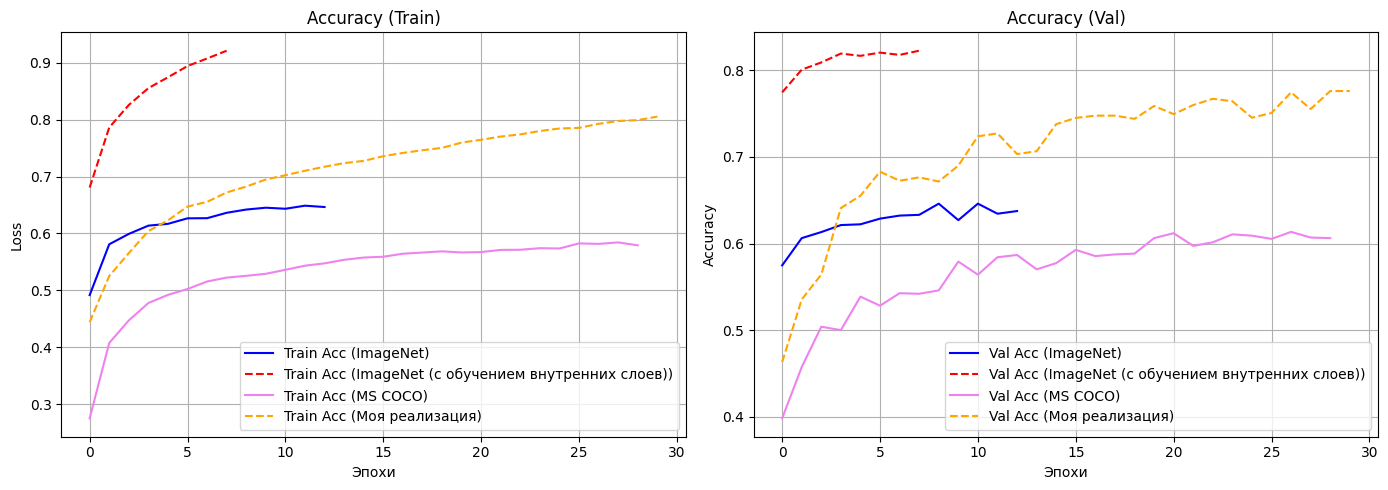

In [22]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_1['train_acc'], label='Train Acc (ImageNet)', color='blue')
plt.plot(history_2['train_acc'], label='Train Acc (ImageNet (с обучением внутренних слоев))', color='red', linestyle='--')
plt.plot(history_3['train_acc'], label='Train Acc (MS COCO)', color='violet')
plt.plot(history_4['train_acc'], label='Train Acc (Моя реализация)', color='orange', linestyle='--')
plt.title('Accuracy (Train)')
plt.xlabel('Эпохи')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_1['val_acc'], label='Val Acc (ImageNet)', color='blue')
plt.plot(history_2['val_acc'], label='Val Acc (ImageNet (с обучением внутренних слоев))', color='red', linestyle='--')
plt.plot(history_3['val_acc'], label='Val Acc (MS COCO)', color='violet')
plt.plot(history_4['val_acc'], label='Val Acc (Моя реализация)', color='orange', linestyle='--')
plt.title('Accuracy (Val)')
plt.xlabel('Эпохи')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

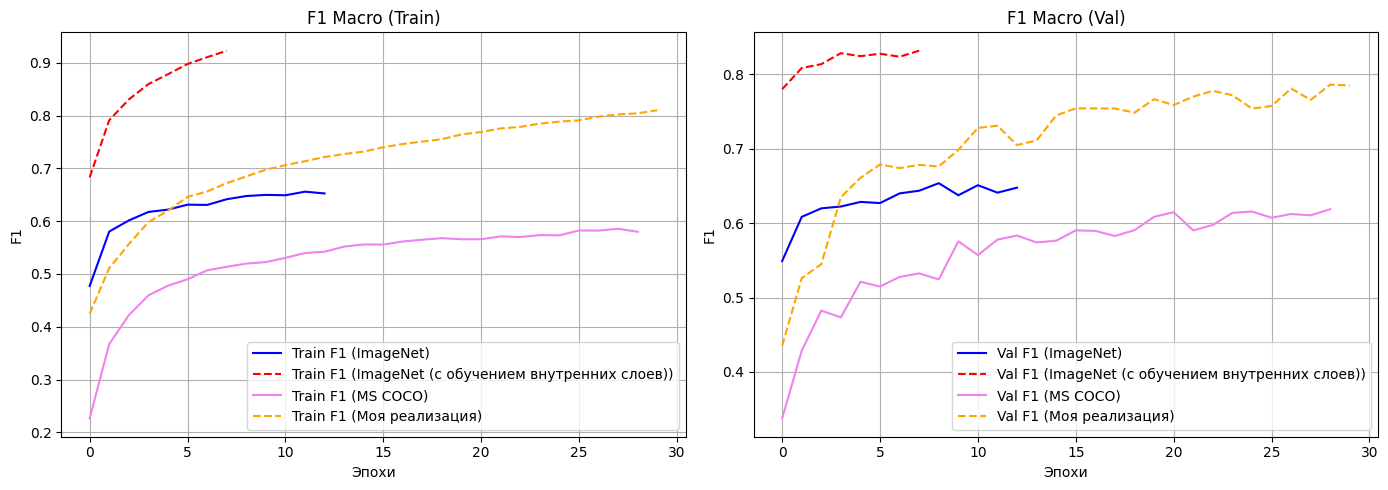

In [23]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_1['train_f1'], label='Train F1 (ImageNet)', color='blue')
plt.plot(history_2['train_f1'], label='Train F1 (ImageNet (с обучением внутренних слоев))', color='red', linestyle='--')
plt.plot(history_3['train_f1'], label='Train F1 (MS COCO)', color='violet')
plt.plot(history_4['train_f1'], label='Train F1 (Моя реализация)', color='orange', linestyle='--')
plt.title('F1 Macro (Train)')
plt.xlabel('Эпохи')
plt.ylabel('F1')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_1['val_f1'], label='Val F1 (ImageNet)', color='blue')
plt.plot(history_2['val_f1'], label='Val F1 (ImageNet (с обучением внутренних слоев))', color='red', linestyle='--')
plt.plot(history_3['val_f1'], label='Val F1 (MS COCO)', color='violet')
plt.plot(history_4['val_f1'], label='Val F1 (Моя реализация)', color='orange', linestyle='--')
plt.title('F1 Macro (Val)')
plt.xlabel('Эпохи')
plt.ylabel('F1')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

##### Сравнение показывает, что лучше всего себя ведет модель с полным переобученим, так как она сумела перекалибровать изначальные веса из под ImageNet под специфику автомобиля и его цветов
##### Собственная модель обученная с нуля, также показала себя лучше двух тяжелых сетей с замороженными весами.Это доказывает, что целенаправленное извлечение признаков бывает эффективнее,чем поиск паттернов в памяти подстроенной под другие задачи
##### Замороженная модель, обученная на ImageNet показала достаточно средний результат. Скорее всего это связано с неспособностью адаптироваться под условия съемки на улице (блики, искажения) и с тем, что изначально она заточена под распознавание объектов, а не их цветов
##### Худший результат показала модель обученная на MS COCO, скорее всего из-за того что ее изначальная задача определять геометрию объектов, не обращая внимания на цветовую информацию